In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd
from scipy import stats

In [3]:
hue_order = ['1', '2', '3']

In [4]:
res_m = []
res_c = []
res_f = []
for exp in ['pOXA48', 'PN23']:
    # read chibio
    m = pd.read_csv(f'../data/{exp}/chibio.tsv.gz', sep='\t')
    m['experiment'] = exp
    # read plate counts
    c = pd.read_csv(f'../data/{exp}/plate_counts.tsv', sep='\t')
    c = c[c['plate'] == 'KAN'].copy().reset_index(drop=True)
    c['experiment'] = exp
    # read plate reader fluorescence
    # p = pd.read_csv(f'data/{exp}/plate_reader_fluorescence.tsv', sep='\t')
    # read flow cytometer
    f = pd.read_csv(f'../data/{exp}/flow_cytometer.tsv', sep='\t')
    f['experiment'] = exp

    if exp == 'pOXA48':
        for df in [m, c, f]:
            df.drop(df[df['replicate'] == 'rep1'].index, inplace=True)
    
    res_m.append(m)
    res_c.append(c)
    res_f.append(f)

m = pd.concat(res_m)
c = pd.concat(res_c)
f = pd.concat(res_f)

for df in [m, c, f]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '').astype(int)
for df in [m, c, f]:
    df.loc[df['experiment'] == 'PN23', 'replicate'] += df.loc[df['experiment'] == 'PN23', 'replicate'].max()

for df in [m, c, f]:
    df['replicate'] -= 1
    df['replicate'] = df['replicate'].astype(str)

In [5]:
m = m[m['name'] == 'TriComm KAN no drug'].copy().reset_index(drop=True)
c = c[c['name'] == 'TriComm KAN no drug'].copy().reset_index(drop=True)
f = f[f['name'] == 'TriComm KAN no drug'].copy().reset_index(drop=True)

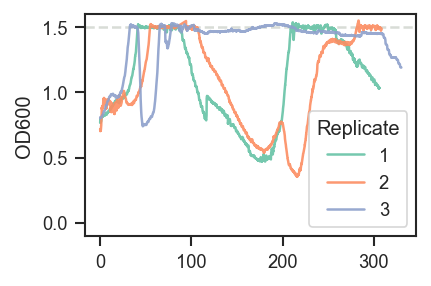

In [6]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_od',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 kind='line',
                 palette='Set2',
                 height=2, aspect=1.5,
                 alpha=0.9,
                )

cp.set(
       xlabel='',
       ylabel='OD600',
       # yscale='log',
       ylim=(-0.1, 1.6)
      )
cp.map(plt.axhline, y=1.5,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

plt.legend(loc='best',
           facecolor='white',
           # fontsize=12,
           title='Replicate',
           # title_fontsize=12
          )
# remove seaborn legend
cp._legend.remove()

sns.despine(top=False,
            right=False)

plt.savefig('kan_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

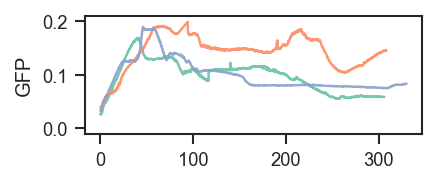

In [7]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP1_emit1',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 kind='line',
                 palette='Set2',
                 height=1.5, aspect=2,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       xlabel='',
       ylabel='GFP',
       ylim=(-0.01, 0.21)
      )

sns.despine(top=False,
            right=False)

plt.savefig('kan_gfp.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_gfp.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

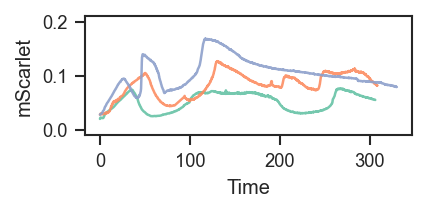

In [8]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP2_emit1',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 kind='line',
                 palette='Set2',
                 height=1.5, aspect=2,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       xlabel='Time',
       ylabel='mScarlet',
       ylim=(-0.01, 0.21)
      )

sns.despine(top=False,
            right=False)

plt.savefig('kan_mscarlet.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_mscarlet.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

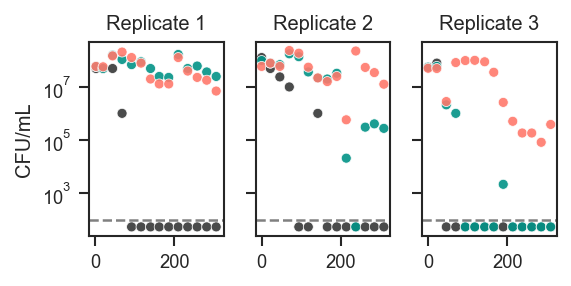

In [9]:
cp = sns.relplot(data=c,
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 # kind='line',
                 col='replicate',
                 # col_wrap=2,
                 height=2, aspect=0.65,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.set(yscale='log',
       xlabel='')
cp.set_titles("Replicate {col_name}",
              fontsize=9)
cp.map(plt.axhline, y=90, color='grey', linestyle='--')

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

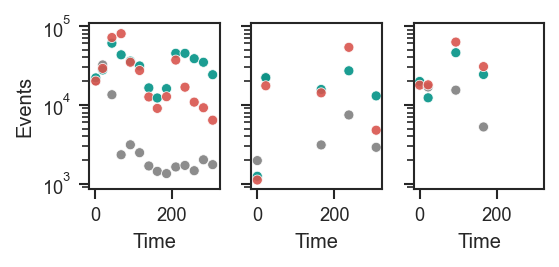

In [10]:
cp = sns.relplot(data=f,
                 x='time',
                 y='events',
                 hue='strain',
                 col='replicate',
                 # col_wrap=2,
                 # row='drug',
                 # style='replicate',
                 height=2, aspect=0.66,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:pale red',
                          'grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.set(yscale='log',
       xlabel='Time',
       ylabel='Events',
       ylim=(8.5E2, 1.1E5))
cp.set_titles("")

sns.despine(top=False,
            right=False)

plt.savefig('kan_flow.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_flow.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

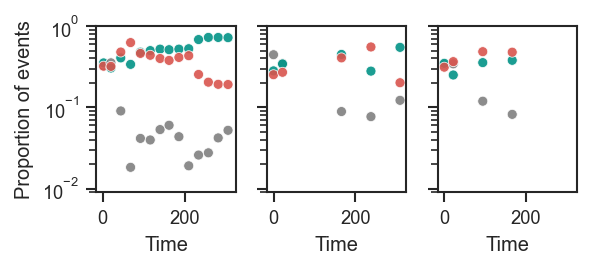

In [11]:
cp = sns.relplot(data=f,
                 x='time',
                 y='proportion',
                 hue='strain',
                 col='replicate',
                 # col_wrap=2,
                 # row='drug',
                 # style='replicate',
                 height=2, aspect=0.66,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:pale red',
                          'grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.set(
       yscale='log',
       xlabel='Time',
       ylabel='Proportion of events',
       ylim=(0.009, 1.01))
cp.set_titles("")

sns.despine(top=False,
            right=False)

plt.savefig('kan_flow_prop.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_flow_prop.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [12]:
n = m.copy()
# shift by 6 minutes to allow for pairing of end time points
n['time'] = [round(float(x+0.1), 0) for x in n['time']]
d = c.copy()
d['time'] = [round(float(x), 0) for x in d['time']]
d['log_CFU/mL'] = np.log10(d['CFU/mL'])
# n = n.set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
n = n.groupby(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).mean()
d = d.set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
g = f.set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [13]:
# chibio vs plate counting
o = n.join(d, 
           how='inner').reset_index()
o['log_cfu'] = np.log(o['CFU/mL'])

In [14]:
o[o['strain'] == 'PL'][['smooth_norm_FP1_emit1', 'CFU/mL', 'log_cfu']].corr()

,smooth_norm_FP1_emit1,CFU/mL,log_cfu
smooth_norm_FP1_emit1,1.000000,0.129844,0.105357
CFU/mL,0.129844,1.000000,0.676318
log_cfu,0.105357,0.676318,1.000000


In [15]:
o[o['strain'] == 'PM'][['smooth_norm_FP2_emit1', 'CFU/mL', 'log_cfu']].corr()

,smooth_norm_FP2_emit1,CFU/mL,log_cfu
smooth_norm_FP2_emit1,1.000000,-0.307172,-0.321520
CFU/mL,-0.307172,1.000000,0.719821
log_cfu,-0.321520,0.719821,1.000000


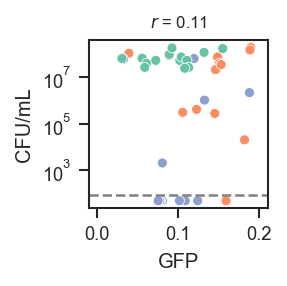

In [16]:
rp = sns.relplot(data=o[o['strain'] == 'PL'],
                 x='smooth_norm_FP1_emit1',
                 y='CFU/mL',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 legend=False)

rp.set(
    yscale='log',
    xlabel='GFP',
    xlim=(-0.01, 0.21)
)

plt.title(f"$r$ = {o[o['strain'] == 'PL'][['smooth_norm_FP1_emit1', 'log_cfu']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

rp.map(plt.axhline, y=90, color='grey', linestyle='--')

plt.savefig('kan_chibio_counting_gfp.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_counting_gfp.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


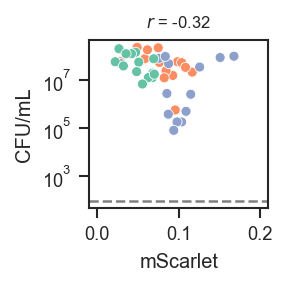

In [17]:
rp = sns.relplot(data=o[o['strain'] == 'PM'],
                 x='smooth_norm_FP2_emit1',
                 y='CFU/mL',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 legend=False)

rp.set(
    yscale='log',
    xlabel='mScarlet',
    # ylabel='',
    xlim=(-0.01, 0.21)
)

plt.title(f"$r$ = {o[o['strain'] == 'PM'][['smooth_norm_FP2_emit1', 'log_cfu']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

rp.map(plt.axhline, y=90, color='grey', linestyle='--')

plt.savefig('kan_chibio_counting_mscarlet.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_counting_mscarlet.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [18]:
# chibio vs flow
o = n.join(g, 
           how='inner').reset_index()
o['log_events'] = np.log10(o['events'])

In [19]:
o[o['strain'] == 'PL'][['smooth_norm_FP1_emit1', 'events', 'log_events']].corr()

,smooth_norm_FP1_emit1,events,log_events
smooth_norm_FP1_emit1,1.000000,0.182107,0.229073
events,0.182107,1.000000,0.853022
log_events,0.229073,0.853022,1.000000


In [20]:
o[o['strain'] == 'PM'][['smooth_norm_FP2_emit1', 'events', 'log_events']].corr()

,smooth_norm_FP2_emit1,events,log_events
smooth_norm_FP2_emit1,1.000000,-0.079673,0.048080
events,-0.079673,1.000000,0.860922
log_events,0.048080,0.860922,1.000000


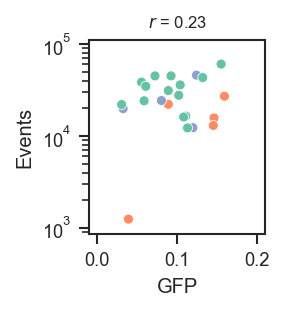

In [21]:
rp = sns.relplot(data=o[o['strain'] == 'PL'],
                 x='smooth_norm_FP1_emit1',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1.05,
                 legend=False)

rp.set(
    yscale='log',
    xlabel='GFP',
    ylabel='Events',
    xlim=(-0.01, 0.21),
    ylim=(8.5E2, 1.1E5)
)

plt.title(f"$r$ = {o[o['strain'] == 'PL'][['smooth_norm_FP1_emit1', 'log_events']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_chibio_flow_gfp.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_flow_gfp.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


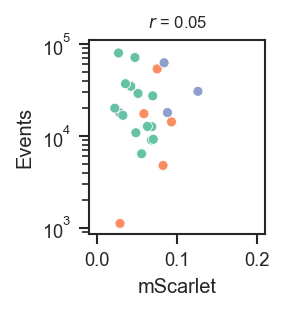

In [22]:
rp = sns.relplot(data=o[o['strain'] == 'PM'],
                 x='smooth_norm_FP2_emit1',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1.05,
                 legend=False)

rp.set(
    yscale='log',
    xlabel='mScarlet',
    ylabel='Events',
    xlim=(-0.01, 0.21),
    ylim=(8.5E2, 1.1E5)
)

plt.title(f"$r$ = {o[o['strain'] == 'PM'][['smooth_norm_FP2_emit1', 'log_events']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_chibio_flow_mscarlet.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_flow_mscarlet.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [23]:
e = d.reset_index().set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
h = f.reset_index().set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])

In [24]:
# plate counting vs flow
o = e.join(h, 
           how='inner').reset_index()

In [25]:
o[(o['strain'] == 'PL') &
  (o['CFU/mL'] > 0)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.000000,-0.101131
log10(events),-0.101131,1.000000


In [26]:
o[(o['strain'] == 'PM') &
  (o['CFU/mL'] > 0)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.000000,0.667335
log10(events),0.667335,1.000000


In [27]:
o[(o['strain'] == 'LM') &
  (o['CFU/mL'] > 0)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.000000,0.683778
log10(events),0.683778,1.000000


In [28]:
o[(o['strain'] == 'PL') &
  (o['CFU/mL'] > 50)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.00000,0.21076
log10(events),0.21076,1.00000


In [29]:
o[(o['strain'] == 'PM') &
  (o['CFU/mL'] > 50)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.000000,0.667335
log10(events),0.667335,1.000000


In [30]:
o[(o['strain'] == 'LM') &
  (o['CFU/mL'] > 50)][['log_CFU/mL', 'log10(events)']].corr()

,log_CFU/mL,log10(events)
log_CFU/mL,1.000000,0.428572
log10(events),0.428572,1.000000


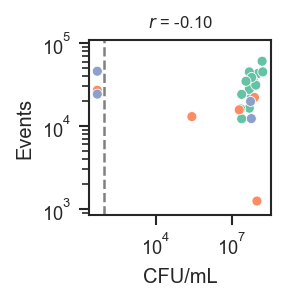

In [31]:
rp = sns.relplot(data=o[o['strain'] == 'PL'],
                 x='CFU/mL',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2.1, aspect=0.95,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylabel='Events',
    ylim=(8.5E2, 1.1E5)
)

plt.title(f"$r$ = {o[o['strain'] == 'PL'][['log_CFU/mL', 'log10(events)']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

rp.map(plt.axvline, x=90, color='grey', linestyle='--')

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting_flow_gfp.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_gfp.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


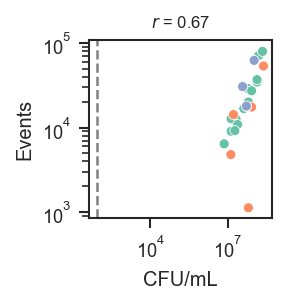

In [32]:
rp = sns.relplot(data=o[o['strain'] == 'PM'],
                 x='CFU/mL',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylabel='Events',
    ylim=(8.5E2, 1.1E5)
)

rp.map(plt.axvline, x=90, color='grey', linestyle='--')

plt.title(f"$r$ = {o[o['strain'] == 'PM'][['log_CFU/mL', 'log10(events)']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting_flow_mScarlet.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_mScarlet.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


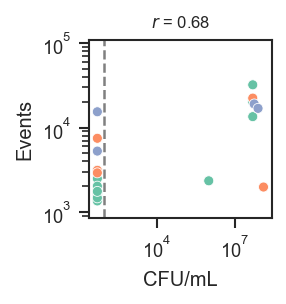

In [33]:
rp = sns.relplot(data=o[o['strain'] == 'LM'],
                 x='CFU/mL',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylabel='Events',
    ylim=(8.5E2, 1.1E5)
)

rp.map(plt.axvline, x=90, color='grey', linestyle='--')

plt.title(f"$r$ = {o[o['strain'] == 'LM'][['log_CFU/mL', 'log10(events)']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting_flow_blank.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_blank.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


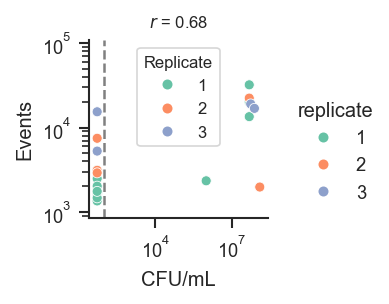

In [34]:
rp = sns.relplot(data=o[o['strain'] == 'LM'],
                 x='CFU/mL',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 # legend=False
                )

rp.set(
    yscale='log',
    xscale='log',
    ylabel='Events',
    ylim=(8.5E2, 1.1E5)
)

rp.map(plt.axvline, x=90, color='grey', linestyle='--')

plt.legend(loc='best',
           facecolor='white',
           fontsize=8,
           title='Replicate',
           title_fontsize=8
          )

plt.title(f"$r$ = {o[o['strain'] == 'LM'][['log_CFU/mL', 'log10(events)']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

# sns.despine(top=False,
#             right=False)

plt.savefig('kan_counting_flow_blank_for_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_blank_for_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


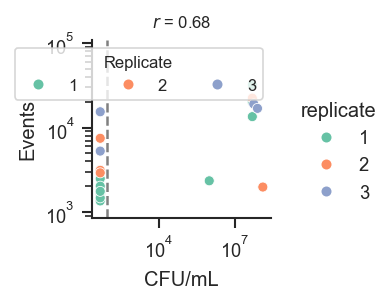

In [35]:
rp = sns.relplot(data=o[o['strain'] == 'LM'],
                 x='CFU/mL',
                 y='events',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1,
                 # legend=False
                )

rp.set(
    yscale='log',
    xscale='log',
    ylabel='Events',
    ylim=(8.5E2, 1.1E5)
)

rp.map(plt.axvline, x=90, color='grey', linestyle='--')

plt.legend(loc='best',
           facecolor='white',
           fontsize=8,
           title='Replicate',
           title_fontsize=8,
           ncols=3
          )

plt.title(f"$r$ = {o[o['strain'] == 'LM'][['log_CFU/mL', 'log10(events)']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

# sns.despine(top=False,
#             right=False)

plt.savefig('kan_counting_flow_blank_for_legend_2.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_blank_for_legend_2.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


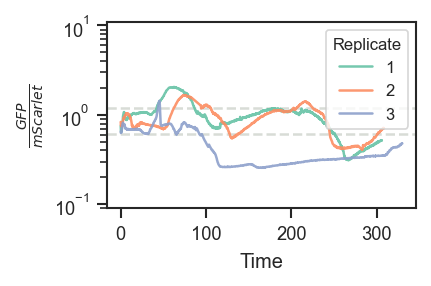

In [36]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 kind='line',
                 palette='Set2',
                 height=2, aspect=1.5,
                 alpha=0.9,
                )

cp.set(
       yscale='log',
       ylim=(0.09, 11),
       ylabel=r'$\frac{GFP}{mScarlet}$',
       xlabel='Time'
      )

cp.map(plt.axhline, y=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

plt.legend(loc='best',
           facecolor='white',
           fontsize=8,
           title='Replicate',
           title_fontsize=8
          )
# remove seaborn legend
cp._legend.remove()

sns.despine(top=False,
            right=False)

plt.savefig('kan_chibio_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [37]:
cr = c.groupby(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

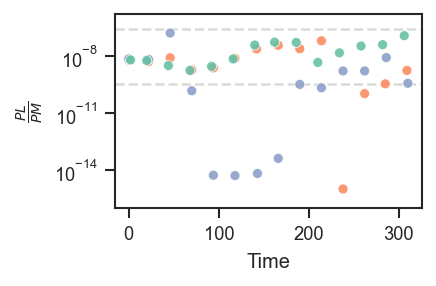

In [38]:
cp = sns.relplot(data=cr[cr['plate'] == 'KAN'],
                 x='time',
                 y='PL / PM',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 # kind='line',
                 palette='Set2',
                 height=2, aspect=1.5,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(9E-17, 1.5E-6)
      )

cp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [39]:
fr = f.groupby(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).apply(
               lambda x: (x[x['strain'] == 'PL']['events'].mean() /
                          x[x['strain'] == 'PM']['events'].mean()),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

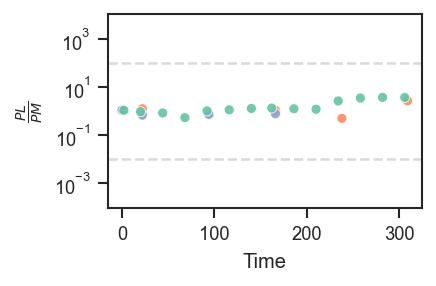

In [40]:
cp = sns.relplot(data=fr,
                 x='time',
                 y='PL / PM',
                 # style='replicate',
                 # hue='experiment',
                 hue='replicate',
                 hue_order=hue_order,
                 # kind='line',
                 palette='Set2',
                 height=2, aspect=1.5,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(0.00009, 11000)
      )

cp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(top=False,
            right=False)

plt.savefig('kan_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [41]:
cr = cr.set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
fr = fr.set_index(['experiment', 'vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [42]:
o = n.join(cr,
           how='inner').reset_index()

In [43]:
o[['smooth_norm_FP1_emit1_FP2_emit1_ratio',
   'PL / PM']].corr()

,smooth_norm_FP1_emit1_FP2_emit1_ratio,PL / PM
smooth_norm_FP1_emit1_FP2_emit1_ratio,1.000000,0.221963
PL / PM,0.221963,1.000000


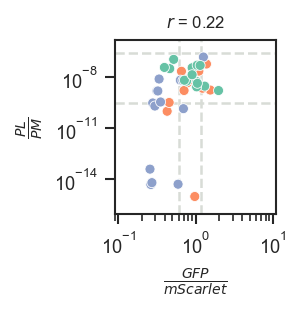

In [44]:
rp = sns.relplot(data=o,
                 x='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 y='PL / PM',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1.05,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylim=(9E-17, 1.5E-6),
    xlim=(0.09, 11),
    xlabel=r'$\frac{GFP}{mScarlet}$',
    ylabel=r'$\frac{PL}{PM}$'
)

rp.map(plt.axvline, x=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axvline, x=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

rp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

plt.title(f"$r$ = {o[['smooth_norm_FP1_emit1_FP2_emit1_ratio', 'PL / PM']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_chibio_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [45]:
o = n.join(fr,
           how='inner').reset_index()
o['log_chibio'] = np.log(o['smooth_norm_FP1_emit1_FP2_emit1_ratio'])
o['log_counting'] = np.log(o['PL / PM'])

In [46]:
o[['log_chibio',
   'log_counting']].corr()

,log_chibio,log_counting
log_chibio,1.000000,-0.413818
log_counting,-0.413818,1.000000


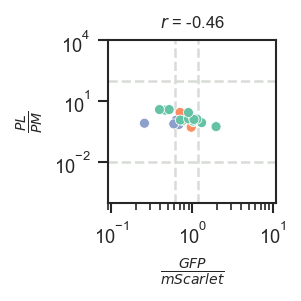

In [47]:
rp = sns.relplot(data=o,
                 x='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 y='PL / PM',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1.05,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylim=(0.00009, 11000),
    xlim=(0.09, 11),
    xlabel=r'$\frac{GFP}{mScarlet}$',
    ylabel=r'$\frac{PL}{PM}$'
)

rp.map(plt.axvline, x=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axvline, x=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

rp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

plt.title(f"$r$ = {o[['smooth_norm_FP1_emit1_FP2_emit1_ratio', 'PL / PM']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_chibio_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_chibio_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [48]:
o = cr.join(fr,
            how='inner',
            lsuffix=' counting',
            rsuffix=' flow').reset_index()
o['log_flow'] = np.log(o['PL / PM flow'])
o['log_counting'] = np.log(o['PL / PM counting'])

In [49]:
o[['log_flow',
   'log_counting']].corr()

,log_flow,log_counting
log_flow,1.00000,0.54172
log_counting,0.54172,1.00000


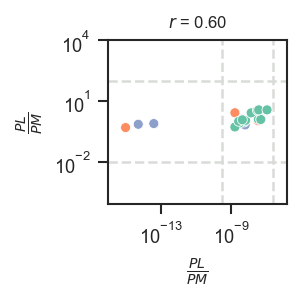

In [50]:
rp = sns.relplot(data=o,
                 x='PL / PM counting',
                 y='PL / PM flow',
                 hue='replicate',
                 hue_order=hue_order,
                 palette='Set2',
                 height=2, aspect=1.05,
                 legend=False)

rp.set(
    yscale='log',
    xscale='log',
    ylim=(0.00009, 11000),
    xlim=(9E-17, 1.5E-6),
    xlabel=r'$\frac{PL}{PM}$',
    ylabel=r'$\frac{PL}{PM}$'
)

rp.map(plt.axvline, x=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axvline, x=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

rp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
rp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

plt.title(f"$r$ = {o[['PL / PM counting', 'PL / PM flow']].corr().iloc[0, 1]:.2f}",
          fontsize=8)

sns.despine(top=False,
            right=False)

plt.savefig('kan_counting_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('kan_counting_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);